In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("daily-min-temperatures.csv")
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


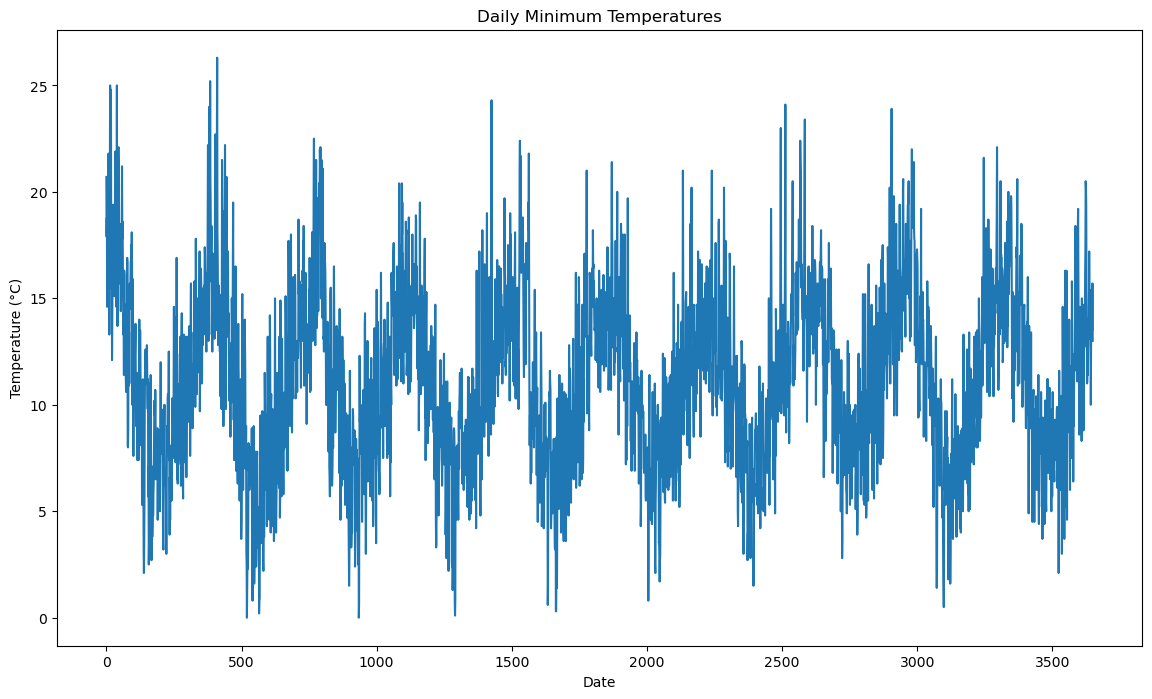

In [4]:
df.plot(title="Daily Minimum Temperatures", figsize=(14,8), legend=None)
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

<h1>Automatic Differencing</h1>

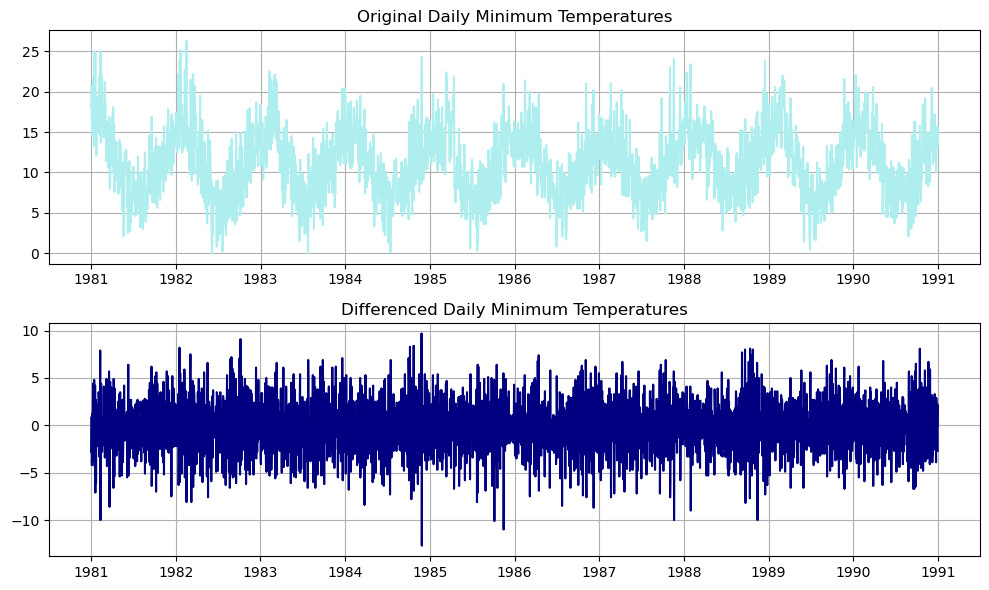

In [8]:
series=pd.read_csv("daily-min-temperatures.csv", header=0, index_col=0, parse_dates=True)
differenced_series=series.diff(periods=1)

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(series, label='Original Series', color='paleturquoise')
plt.title('Original Daily Minimum Temperatures')
plt.grid()

plt.subplot(2,1,2)
plt.plot(differenced_series, label='Differenced Series', color='navy')
plt.title("Differenced Daily Minimum Temperatures")
plt.grid()

plt.tight_layout()
plt.show()

<h1>Manual Differencing</h1>

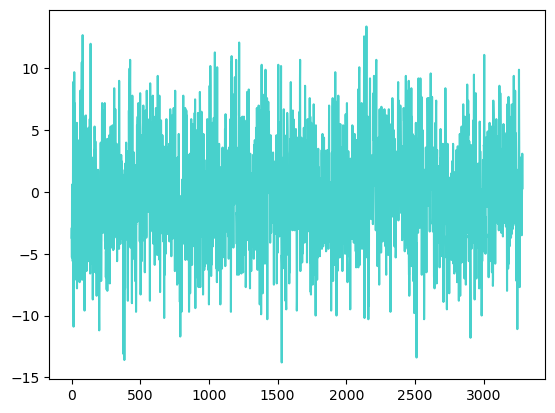

In [11]:
series=pd.read_csv("daily-min-temperatures.csv", header=0, index_col=0)
X=series.values
diff=list()
days_in_year=365
for i in range(days_in_year, len(X)):
    value=X[i] - X[i - days_in_year]
    diff.append(value)

plt.plot(diff, color= 'mediumturquoise')
plt.show()

In [12]:
df_temperature=pd.read_csv("daily-min-temperatures.csv", parse_dates=[0], index_col=0)
print(df_temperature.head())

            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


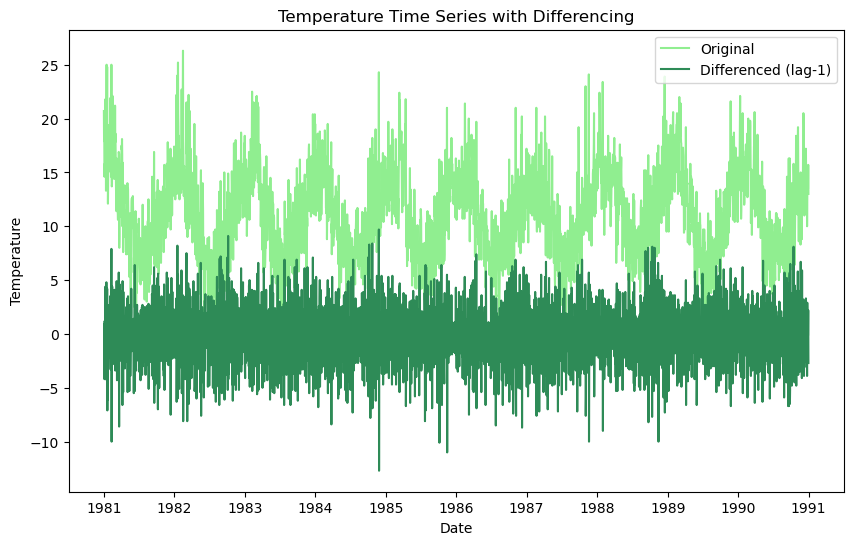

In [13]:
df_temperature['diff']=df_temperature['Temp'].diff(periods=1)

plt.figure(figsize=(10,6))
plt.plot(df_temperature.index, df_temperature['Temp'], label="Original", color='lightgreen')
plt.plot(df_temperature.index, df_temperature['diff'], label="Differenced (lag-1)", color='seagreen')
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Temperature Time Series with Differencing")
plt.legend()
plt.show()

<h1>Fitting Polynomials</h1>

Coefficients: [[-1.17308000e-08]
 [ 9.30253946e-06]
 [-2.15977594e-03]
 [ 1.19147966e-01]
 [ 1.38980178e+01]]


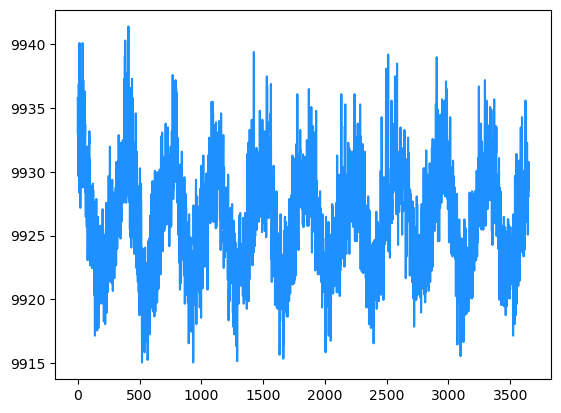

In [16]:
from numpy import polyfit

series=pd.read_csv("daily-min-temperatures.csv", header=0, index_col=0)
X=[i%365 for i in range(0, len(series))]
y=series.values
degree=4
coef=polyfit(X,y,degree)
print("Coefficients: %s" % coef)

curve=list()
for i in range(len(X)):
    value=coef[-1]
    for d in range(degree):
        value += X[i]**(degree-d) * coef[d]
        curve.append(value)

values=series.values
diff=list()
for i in range(len(values)):
    value=values[i] - curve[i]
    diff.append(value)
plt.plot(diff, color='dodgerblue')
plt.show()